<a href="https://colab.research.google.com/github/Aatka-Saleem/ML-Core-Implementations/blob/main/01-Data-Foundations/Data_Preprocessing_and_Feature_Engineering_Handling_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMAGE PREPROCESSING AND AUGMENTATION

The following codes can be run in two ways:
1. Run on your local machine using anaconda.
   - To install TensorFlow2 and Keras on Anaconda, run the following commands on the shell:\
     conda install –c conda-forge tensorflow\
     conda install –c conda-forge keras
     
   - It can also be installed using pip as follows:\
     pip install --upgrade pip\
     pip install tensorflow
     
     
2. Run on Google Colaboratory (CoLab).
   - No installation required.
   - The images and data used in code has to be uploaded (in the files area) afresh everytime   CoLab is used.
   - One trick around is to place all the data and images in Google Drive and mount the drive in Google Colab as shown in the following code. This will save us from uploading the images again anad again everytime use use the notebook.

### Imports

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

### Mounting Google Drive
- This code will mount my google drive on Colab.
- It is requied if Google Colab is used, not required if the code is run on Anaconda.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### Selecting Images

- 3 random images are selected from https://unsplash.com/.
- The website contains high-resolution images from professional photographers.


### Preprocessing Images

**Defining constants for file names along with paths**

In [ ]:
# Set path of the folder containing images or of Google Drive if Google Colab is used

FILE_1 = "/content/Umbrella.jpg"
FILE_2 = "/content/Flower.jpg"
FILE_3 = "/content/Shoe.jpg"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

**Loading images in original resolution**

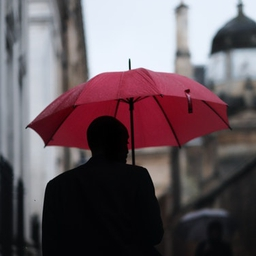

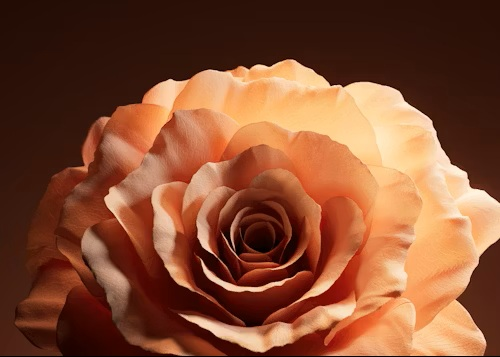

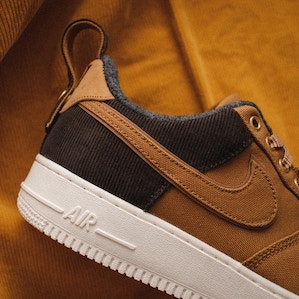

In [ ]:
from tensorflow.keras.utils import load_img

pic1_orig = load_img(FILE_1)
display(pic1_orig)  #Display is a function in module IPython.core.display; displays a Python object in all frontends.

pic2_orig = load_img(FILE_2)
display(pic2_orig)

pic3_orig = load_img(FILE_3)
display(pic3_orig)

# Note the origial resolution of File_1 is 256x256 and that of Image_2 is 299x299.
# Also note the File_3 is rectangular having resolution of 500x357

**Loading images in reduced resolution of 200x200**

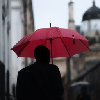

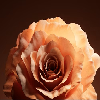

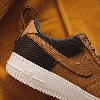

In [ ]:
pic1_reduced = load_img(FILE_1, target_size=(100,100))
display(pic1_reduced)

pic2_reduced = load_img(FILE_2, target_size=(100,100))
display(pic2_reduced)

pic3_reduced = load_img(FILE_3, target_size=(100,100))
display(pic3_reduced)

# First two images are square so aspect ration in maintained in the reduced versions, but image_3 is shrinked horizontally

**Converting images to grayscale**

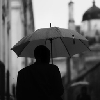

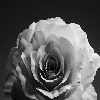

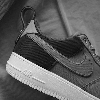

In [ ]:
pic1_reduced_gray = load_img(FILE_1, target_size=(100,100), color_mode="grayscale")
display(pic1_reduced_gray)

pic2_reduced_gray = load_img(FILE_2, target_size=(100,100), color_mode="grayscale")
display(pic2_reduced_gray)

pic3_reduced_gray = load_img(FILE_3, target_size=(100,100), color_mode="grayscale")
display(pic3_reduced_gray)

**Converting colored images to array**

In [ ]:
from tensorflow.keras.utils import img_to_array

pic1_reduced_array = img_to_array(pic1_reduced)
print('Shape of the image array: ',pic1_reduced_array.shape)
print('Datatype of the image array elements: ',pic1_reduced_array.dtype) # takes 4B per color channel per pixel
print('Memory in KiB taken by the image array: ',pic1_reduced_array.nbytes / 1024, ' KB')
print(pic1_reduced_array) # printing the array, note that it is a 3D tensor

Shape of the image array:  (100, 100, 3)
Datatype of the image array elements:  float32
Memory in KiB taken by the image array:  117.1875  KB
[[[133. 140. 150.]
  [145. 149. 160.]
  [117. 122. 126.]
  ...
  [230. 238. 251.]
  [230. 238. 249.]
  [230. 238. 249.]]

 [[132. 139. 149.]
  [146. 150. 159.]
  [114. 119. 123.]
  ...
  [230. 238. 249.]
  [230. 238. 249.]
  [230. 238. 249.]]

 [[134. 141. 149.]
  [145. 148. 157.]
  [112. 117. 121.]
  ...
  [231. 239. 250.]
  [230. 238. 249.]
  [230. 238. 249.]]

 ...

 [[ 15.  16.  18.]
  [ 10.  11.  13.]
  [  9.  10.  12.]
  ...
  [ 16.  14.  15.]
  [ 17.  15.  16.]
  [ 18.  16.  17.]]

 [[ 12.  13.  17.]
  [ 10.  11.  15.]
  [  9.  10.  12.]
  ...
  [ 19.  18.  14.]
  [ 18.  16.  17.]
  [ 18.  17.  15.]]

 [[ 22.  23.  28.]
  [ 10.  11.  15.]
  [  9.  10.  12.]
  ...
  [ 17.  16.  12.]
  [ 18.  16.  17.]
  [ 17.  15.  16.]]]


**Converting grayscale image (File_1 only) to array**

In [ ]:
pic1_reduced_gray_array = img_to_array(pic1_reduced_gray)
print('Shape of the image array: ',pic1_reduced_gray_array.shape)
print('Datatype of the image array elements: ',pic1_reduced_gray_array.dtype) # takes 4B per color channel per pixel
print('Memory in KiB taken by the image array: ',pic1_reduced_gray_array.nbytes / 1024, ' KB')
print(pic1_reduced_gray_array) # printing the array, note that it is a 3D tensor

Shape of the image array:  (100, 100, 1)
Datatype of the image array elements:  float32
Memory in KiB taken by the image array:  39.0625  KB
[[[139.]
  [149.]
  [121.]
  ...
  [237.]
  [237.]
  [237.]]

 [[138.]
  [150.]
  [118.]
  ...
  [237.]
  [237.]
  [237.]]

 [[140.]
  [148.]
  [116.]
  ...
  [238.]
  [237.]
  [237.]]

 ...

 [[ 16.]
  [ 11.]
  [ 10.]
  ...
  [ 15.]
  [ 16.]
  [ 17.]]

 [[ 13.]
  [ 11.]
  [ 10.]
  ...
  [ 18.]
  [ 17.]
  [ 17.]]

 [[ 23.]
  [ 11.]
  [ 10.]
  ...
  [ 16.]
  [ 17.]
  [ 16.]]]


**Converting gray scale image (File_1 only) to binary**

In [ ]:
pic1_reduced_binary = (pic1_reduced_gray_array >= 180).astype(np.uint8)
print('Shape of the image array: ',pic1_reduced_binary.shape)
print('Datatype of the image array elements: ',pic1_reduced_binary.dtype) # takes 1B per color channel per pixel
print('Memory in KiB taken by the image array: ',pic1_reduced_binary.nbytes / 1024, ' KB')
print(pic1_reduced_binary) # printing the array, note that it is a 3D tensor

Shape of the image array:  (100, 100, 1)
Datatype of the image array elements:  uint8
Memory in KiB taken by the image array:  9.765625  KB
[[[0]
  [0]
  [0]
  ...
  [1]
  [1]
  [1]]

 [[0]
  [0]
  [0]
  ...
  [1]
  [1]
  [1]]

 [[0]
  [0]
  [0]
  ...
  [1]
  [1]
  [1]]

 ...

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]]


**Displaying this binary image**

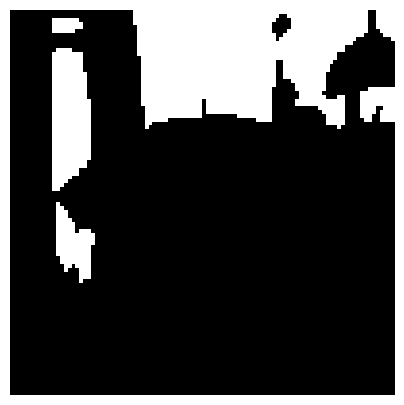

In [ ]:
# Displaying binary image as pixel matrix using matplotlib
plt.figure(figsize=(5,5))
plt.imshow(pic1_reduced_binary, cmap=plt.cm.gray)
plt.axis('off')
plt.show()

# Hope you remeber the original umbrella image

**Normalizing grayscale image (File_1 only)**

In [ ]:
pic1_reduced_gray_array_normalized = pic1_reduced_gray_array/255
print('Minimum value: ', pic1_reduced_gray_array_normalized.min())
print('Maximum value: ', pic1_reduced_gray_array_normalized.max())
print(pic1_reduced_gray_array_normalized)

Minimum value:  0.0
Maximum value:  0.9843137
[[[0.54509807]
  [0.58431375]
  [0.4745098 ]
  ...
  [0.92941177]
  [0.92941177]
  [0.92941177]]

 [[0.5411765 ]
  [0.5882353 ]
  [0.4627451 ]
  ...
  [0.92941177]
  [0.92941177]
  [0.92941177]]

 [[0.54901963]
  [0.5803922 ]
  [0.45490196]
  ...
  [0.93333334]
  [0.92941177]
  [0.92941177]]

 ...

 [[0.0627451 ]
  [0.04313726]
  [0.03921569]
  ...
  [0.05882353]
  [0.0627451 ]
  [0.06666667]]

 [[0.05098039]
  [0.04313726]
  [0.03921569]
  ...
  [0.07058824]
  [0.06666667]
  [0.06666667]]

 [[0.09019608]
  [0.04313726]
  [0.03921569]
  ...
  [0.0627451 ]
  [0.06666667]
  [0.0627451 ]]]


**Applying some simple augnetations to grayscale image (File_1 only)**

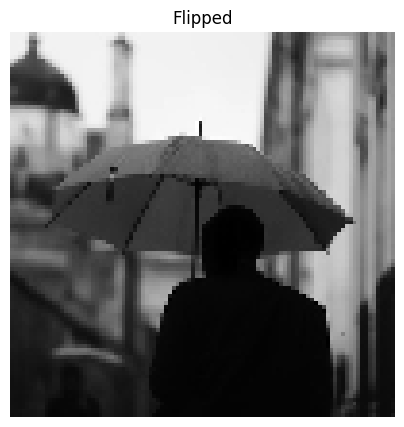

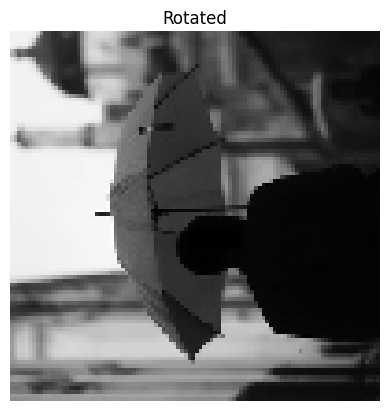

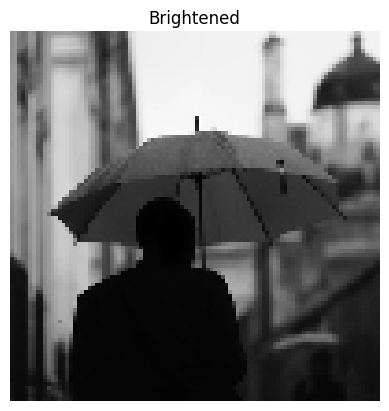

In [ ]:
# Convert NumPy array to Tensor
img_tensor = tf.convert_to_tensor(pic1_reduced_gray_array, dtype=tf.float32)

# Add a batch dimension (required by tf.image functions)
img_tensor = tf.expand_dims(img_tensor, axis=0)  # shape: (1, H, W, 1)

# Simple augmentations
pic1_flipped = tf.image.flip_left_right(img_tensor)   # horizontal flip
pic1_rotated = tf.image.rot90(img_tensor)             # 90-degree rotation
pic1_brightened = tf.image.adjust_brightness(img_tensor, delta=0.2)  # brighten

# Remove batch dimension for visualization
pic1_flipped = tf.squeeze(pic1_flipped)
pic1_rotated = tf.squeeze(pic1_rotated)
pic1_brightened = tf.squeeze(pic1_brightened)

plt.figure(figsize=(5,5))
plt.imshow(pic1_flipped, cmap=plt.cm.gray)
plt.axis('off')
plt.title('Flipped')
plt.show()

plt.imshow(pic1_rotated, cmap=plt.cm.gray)
plt.axis('off')
plt.title('Rotated')
plt.show()

plt.imshow(pic1_brightened, cmap=plt.cm.gray)
plt.axis('off')
plt.title('Brightened')
plt.show()

# Notice that the effect of brighness is not very visible in grayscale images.

### Task for you

Search and try out other augmentation tachniques.

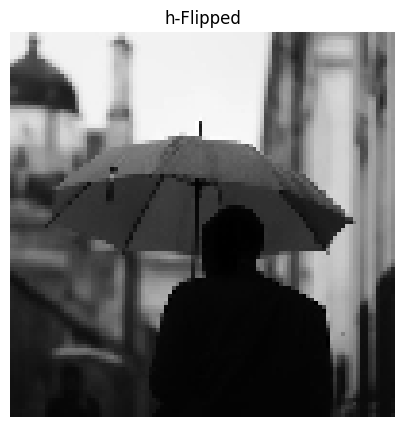

In [ ]:
# Horizontal flip
pic_h_flipped = tf.image.flip_left_right(img_tensor)

pic_h_flipped = tf.squeeze(pic_h_flipped)

plt.figure(figsize=(5,5))
plt.imshow(pic1_flipped, cmap=plt.cm.gray)
plt.axis('off')
plt.title('h-Flipped')
plt.show()

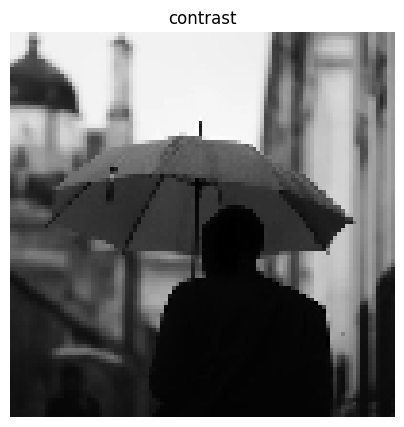

In [ ]:
# Adjust contrast by a factor (e.g., 0.5)
pic_contrast = tf.image.adjust_contrast(img_tensor, contrast_factor=0.5)

pic_contrast = tf.squeeze(pic_contrast)

plt.figure(figsize=(5,5))
plt.imshow(pic1_flipped, cmap=plt.cm.gray)
plt.axis('off')
plt.title('contrast')
plt.show()

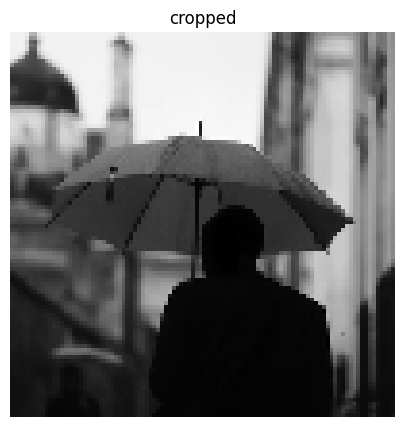

In [ ]:
# Crop to the central 80% of the image
pic_cropped = tf.image.central_crop(img_tensor, central_fraction=0.8)

pic_cropped = tf.squeeze(pic_cropped)

plt.figure(figsize=(5,5))
plt.imshow(pic1_flipped, cmap=plt.cm.gray)
plt.axis('off')
plt.title('cropped')
plt.show()

In [ ]:
# Increase saturation (only for RGB images)
pic_saturated = tf.image.adjust_saturation(img_tensor, saturation_factor=2.0)

pic_saturated  = tf.squeeze(pic_saturated )

plt.figure(figsize=(5,5))
plt.imshow(pic1_flipped, cmap=plt.cm.gray)
plt.axis('off')
plt.title('saturated ')
plt.show()

InvalidArgumentError: {{function_node __wrapped__AdjustSaturation_device_/job:localhost/replica:0/task:0/device:GPU:0}} input must have 3 channels but instead has 1 channels. [Op:AdjustSaturation] name: 

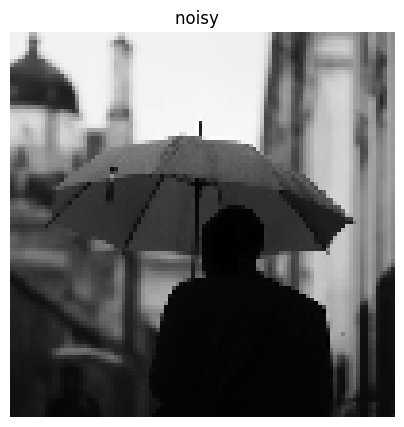

In [ ]:
# Add random noise
noise = tf.random.normal(shape=tf.shape(img_tensor), mean=0.0, stddev=0.1, dtype=tf.float32)
pic_noisy = img_tensor + noise

pic_noisy   = tf.squeeze(pic_noisy  )

plt.figure(figsize=(5,5))
plt.imshow(pic1_flipped, cmap=plt.cm.gray)
plt.axis('off')
plt.title('noisy  ')
plt.show()